### 使用一个额外ancilla的情形

In [27]:
import numpy as np
from TDD.TDD import TDD, Ini_TDD,Clear_TDD,set_index_order,get_unique_table_num,set_root_of_unit,get_count,cont,renormalize,Slicing2,Slicing
from TDD.TDD_Q import cir_2_tn,get_real_qubit_num,add_trace_line,add_inputs,add_outputs,gen_cir
from TDD.TN import Index,Tensor,TensorNetwork
from TDD.Syn import *
import time
import random
from qiskit import QuantumCircuit,qasm2, transpile
import cProfile
from IPython.display import display, HTML,Image
# from PIL import Image
from PIL import Image as PILImage
import networkx as nx
import copy
from qiskit.circuit.library.standard_gates import HGate,U1Gate,U3Gate
from qiskit.quantum_info.operators import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.circuit import CircuitInstruction

import itertools

to_test = False

import warnings

warnings.simplefilter("ignore")

In [35]:
def oracle_syn2(tdd,n=0,cond={},data_q = -1):

    if n==0:
        n = tdd.node.key+1
    cir = Circuit(n+2,[])
    qa = n
    data_q = n+1
    
    if tdd.node.key==-1:
        cir.data.append(Gate('x',{qa:1},data_q))
        return cir
        

    u = tdd.node
    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father
    
    the_map = u.out_maps[1]
    while the_map.level>-1:
            q1 = u.key
            idx = the_map.level
            q = int(tdd.key_2_index[idx][1:])
            if the_map.x==1:
                cir.data.append(Gate('x',{qa:1,q1:1},q))
            the_map=the_map.father

    
    if u.successor[0]!=u.successor[1]:
        #把1分支关闭
        cond_n = copy.copy(cond)
        cond_n[u.key] = 1
        cir.data.append(Gate('x',cond_n,qa))

        bran_tdd = get_branch_dd(u,0)
        cir_end_t0 = oracle_syn2(bran_tdd,n,cond|{u.key:0},data_q)
        cir.data=cir.data+cir_end_t0.data
    
        #把0分支关闭，1分支打开
        cir.data.append(Gate('x',cond,qa))

        bran_tdd = get_branch_dd(u,1)
        cir_end_t1 = oracle_syn2(bran_tdd,n,cond|{u.key:1},data_q)
        cir.data=cir.data+cir_end_t1.data
        
        #把0分支再打开
        cond_n = copy.copy(cond)
        cond_n[u.key] = 0
        cir.data.append(Gate('x',cond_n,qa))
    else:
        bran_tdd = get_branch_dd(u,0)
        cir_end_t0 = oracle_syn2(bran_tdd,n,cond,data_q)
        if abs(u.out_weight[1])<1e-10:
            cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1)
        cir.data=cir.data+cir_end_t0.data
  
    the_map = u.out_maps[1]
    while the_map.level>-1:
        q1 = u.key
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{qa:1,q1:1},q))
        the_map=the_map.father
            
    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father
    return cir

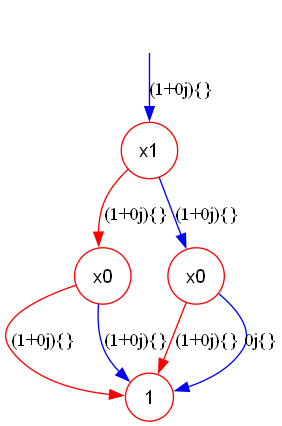

In [29]:
tdd = get_ramdom_TDD(2)
tdd.show()

In [36]:
t_start = time.time()
cir = oracle_syn2(tdd)
print(time.time()-t_start)
print(cir)

0.0009772777557373047
[('x', '(1: 1)', 2, array([[0, 1],
       [1, 0]])),('x', '(2: 1)', 3, array([[0, 1],
       [1, 0]])),('x', '()', 2, array([[0, 1],
       [1, 0]])),('x', '(2: 1, 0: 0)', 3, array([[0, 1],
       [1, 0]])),('x', '(1: 0)', 2, array([[0, 1],
       [1, 0]])),]


0.0009996891021728516


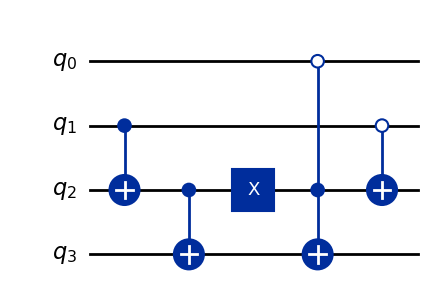

In [37]:
t_start = time.time()
cir_qis = cir.to_qis_cir()
print(time.time()-t_start)
cir_qis.draw('mpl')